<a href="https://colab.research.google.com/github/AmatHub21/Implementasi_DataMining/blob/main/DM06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# bagging_rf.py
# ================================

import numpy as np
import pandas as pd
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Perbandingan Akurasi
print("=" * 50)
print("Perbandingan Akurasi")
print(f"Decision Tree : {accuracy_score(y_test, dt_pred):.4f}")
print(f"Bagging       : {accuracy_score(y_test, bagging_pred):.4f}")
print(f"Random Forest : {accuracy_score(y_test, rf_pred):.4f}")

# Feature Importance
importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Feature Importance")
print(importance.head())

Perbandingan Akurasi
Decision Tree : 0.9415
Bagging       : 0.9591
Random Forest : 0.9708

Top 5 Feature Importance
                 feature  importance
7    mean concave points    0.141934
27  worst concave points    0.127136
23            worst area    0.118217
6         mean concavity    0.080557
20          worst radius    0.077975


Perbandingan Boosting Methods
AdaBoost          : 0.9708
Gradient Boosting : 0.9591

Top 5 Feature Importance
                 feature  importance
7    mean concave points    0.434897
27  worst concave points    0.273841
22       worst perimeter    0.050974
23            worst area    0.047995
21         worst texture    0.047193


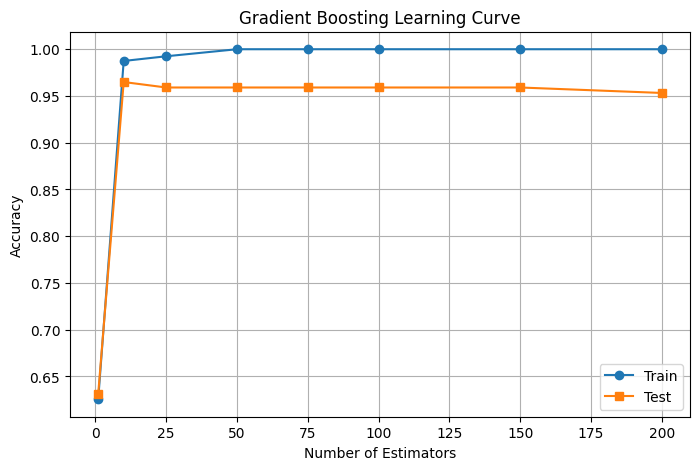

In [2]:
# ================================
# boosting_models.py
# ================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# Evaluasi
print("=" * 50)
print("Perbandingan Boosting Methods")
print(f"AdaBoost          : {accuracy_score(y_test, ada_pred):.4f}")
print(f"Gradient Boosting : {accuracy_score(y_test, gb_pred):.4f}")

# Feature Importance
gb_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Feature Importance")
print(gb_importance.head())

# Learning Curve
train_scores = []
test_scores = []

estimators = [1, 10, 25, 50, 75, 100, 150, 200]

for n in estimators:
    gb_temp = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    gb_temp.fit(X_train, y_train)

    train_scores.append(gb_temp.score(X_train, y_train))
    test_scores.append(gb_temp.score(X_test, y_test))

# Visualisasi
plt.figure(figsize=(8, 5))

plt.plot(
    estimators,
    train_scores,
    label='Train',
    marker='o'
)

plt.plot(
    estimators,
    test_scores,
    label='Test',
    marker='s'
)

plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting Learning Curve')

plt.legend()
plt.grid(True)

plt.show()

PERBANDINGAN SEMUA METODE
Decision Tree     : 0.9415
Bagging           : 0.9591
Random Forest     : 0.9708
AdaBoost          : 0.9708
Gradient Boosting : 0.9591
Stacking          : 0.9825


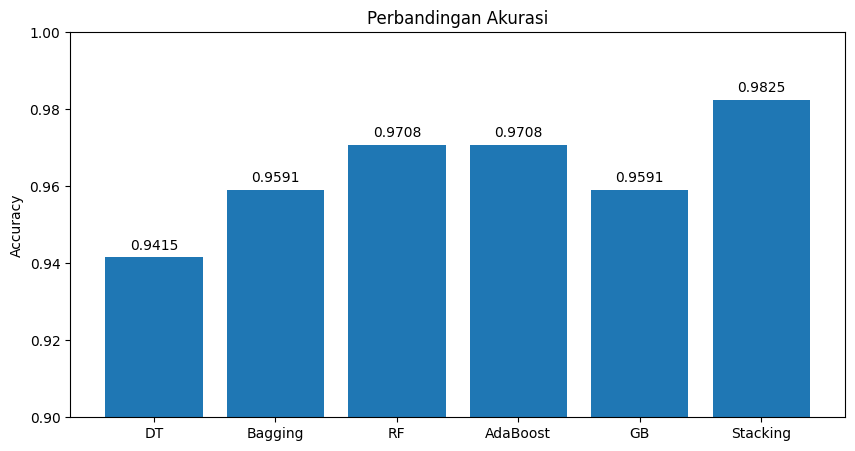

In [3]:
# ================================
# FILE 3: stacking_classifier.py
# ================================

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# Base Models
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=50,
        random_state=42
    )),

    ('svm', SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    )),

    ('knn', KNeighborsClassifier(
        n_neighbors=5
    )),

    ('dt', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
]

# Meta Learner
meta_learner = LogisticRegression(max_iter=1000)

# Stacking
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba'
)

stacking.fit(X_train, y_train)

stacking_pred = stacking.predict(X_test)

# Hasil Akurasi
print("=" * 50)
print("PERBANDINGAN SEMUA METODE")
print("=" * 50)

print(f"Decision Tree     : {accuracy_score(y_test, dt_pred):.4f}")
print(f"Bagging           : {accuracy_score(y_test, bagging_pred):.4f}")
print(f"Random Forest     : {accuracy_score(y_test, rf_pred):.4f}")
print(f"AdaBoost          : {accuracy_score(y_test, ada_pred):.4f}")
print(f"Gradient Boosting : {accuracy_score(y_test, gb_pred):.4f}")
print(f"Stacking          : {accuracy_score(y_test, stacking_pred):.4f}")

# Visualisasi
models = [
    'DT',
    'Bagging',
    'RF',
    'AdaBoost',
    'GB',
    'Stacking'
]

scores = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, bagging_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, ada_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, stacking_pred)
]

plt.figure(figsize=(10, 5))

plt.bar(models, scores)

plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi')

plt.ylim(0.9, 1.0)

for i, v in enumerate(scores):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center')

plt.show()

In [4]:
# ================================
# FILE 4: cv_comparison.py
# ================================

import time
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, KFold

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Base models untuk stacking
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=50,
        random_state=42
    )),

    ('svm', SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    )),

    ('knn', KNeighborsClassifier(
        n_neighbors=5
    ))
]

# Meta learner
meta_learner = LogisticRegression(max_iter=1000)

# Stacking model
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5
)

# Model comparison
models = {
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Stacking': stacking
}

# Cross Validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    start_time = time.time()

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='accuracy'
    )

    elapsed_time = time.time() - start_time

    results.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std': scores.std(),
        'Training Time (s)': elapsed_time
    })

# Hasil
results_df = pd.DataFrame(results).round(4)

print(results_df.to_string(index=False))

# Model terbaik
best_model = results_df.loc[
    results_df['Mean Accuracy'].idxmax(),
    'Model'
]

print(f"\nModel terbaik berdasarkan CV: {best_model}")

            Model  Mean Accuracy    Std  Training Time (s)
    Decision Tree         0.9332 0.0162             0.1195
    Random Forest         0.9578 0.0102             2.2385
         AdaBoost         0.9736 0.0124             3.3395
Gradient Boosting         0.9613 0.0106             5.8012
         Stacking         0.9613 0.0181             6.1095

Model terbaik berdasarkan CV: AdaBoost
